Datos de la leyenda: {'Unknown': '#000000', 'Tierra': '#ffaa00', 'Agua': '#0000ff', 'Aire': '#00ffff'}
Segmentos guardados: [{'end': 6000.0, 'start': 5000.0, 'type': 'Tierra'}, {'end': 7000.0, 'start': 6000.0, 'type': 'Agua'}, {'end': 8000.0, 'start': 7000.0, 'type': 'Aire'}]
Segmentos guardados: [{'end': 5000.0, 'start': 0, 'type': 'Unknown'}, {'end': 6000.0, 'start': 5000.0, 'type': 'Tierra'}, {'end': 7000.0, 'start': 6000.0, 'type': 'Agua'}, {'end': 8000.0, 'start': 7000.0, 'type': 'Aire'}, {'end': 11624.073777733043, 'start': 8000.0, 'type': 'Unknown'}]
Segmentos guardados: [{'end': 5000.0, 'start': 0.0, 'type': 'Unknown'}, {'end': 6000.0, 'start': 5000.0, 'type': 'Tierra'}, {'end': 7000.0, 'start': 6000.0, 'type': 'Agua'}, {'end': 8000.0, 'start': 7000.0, 'type': 'Aire'}, {'end': 11624.0, 'start': 8000.0, 'type': 'Unknown'}, {'end': 11624.073777733043, 'start': 11624.0, 'type': 'Unknown'}]
Segmentos guardados: [{'end': 5000.0, 'start': 0, 'type': 'Unknown'}, {'end': 6000.0, 'start

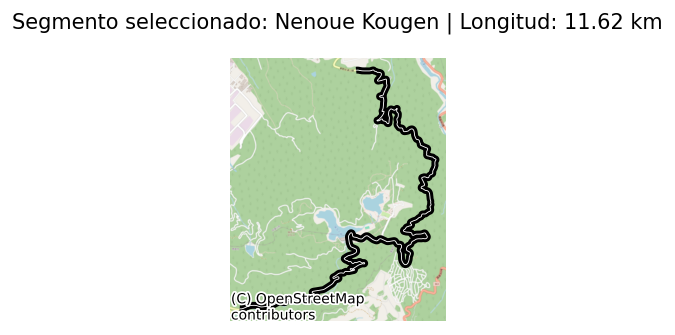

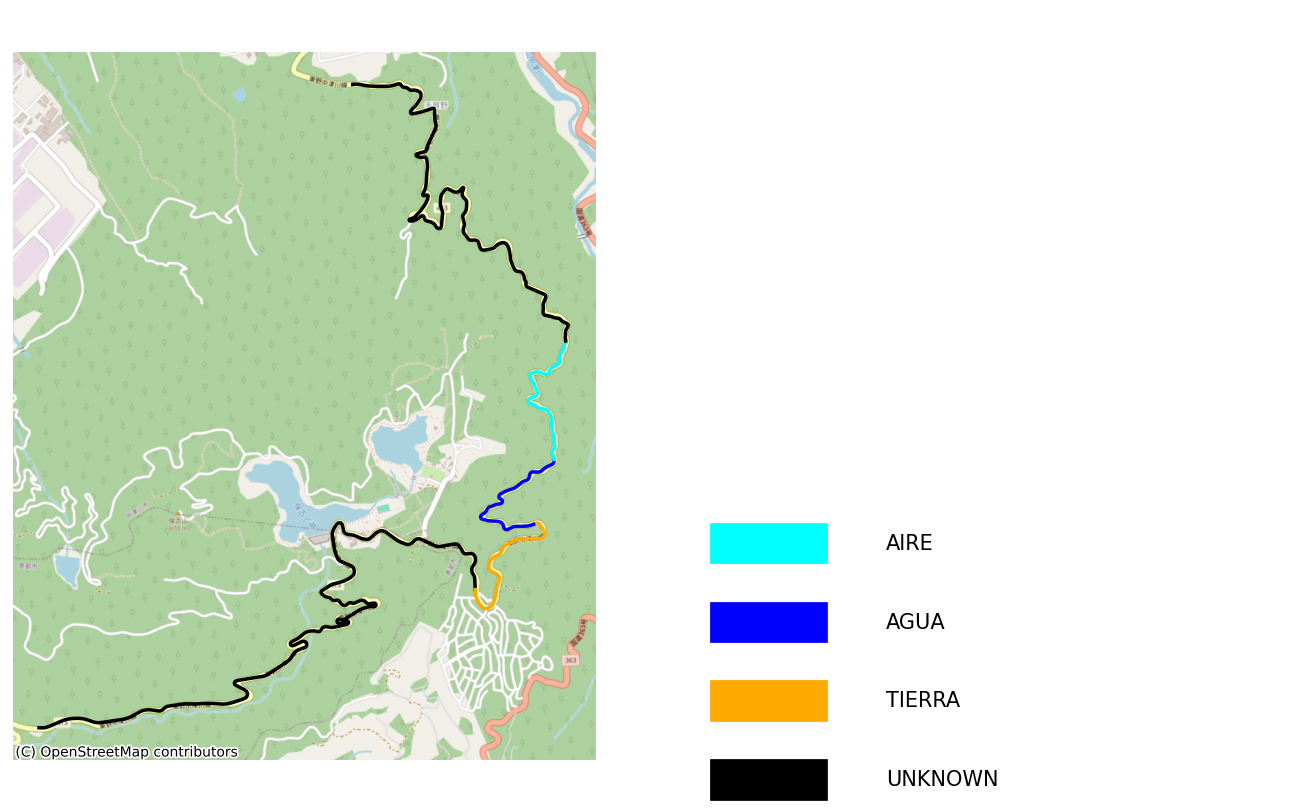

In [6]:
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout, QFileDialog, QComboBox, QListWidget, QColorDialog, QDialog,\
    QInputDialog, QLineEdit, QListWidgetItem, QMessageBox, QSpacerItem, QSizePolicy
from PySide6.QtCore import Qt
from PySide6.QtGui import QColor  # Asegúrate de importar esto
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
from PySide6.QtCore import Signal
import sys
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import contextily as ctx
import math
from shapely.geometry import LineString
from shapely.ops import substring

fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default



def split_line_variable_lengths(gdf_segment, segment_lengths, start_distance=0, end_distance=None):
    """
    Divide una línea en segmentos de longitudes variables especificadas en una lista.

    Parameters:
        gdf_segment (GeoDataFrame): GeoDataFrame con un único LineString en la columna 'geometry'.
        segment_lengths (list): Lista con las longitudes de cada segmento.

    Returns:
        GeoDataFrame: Nuevo GeoDataFrame con los segmentos generados.
    """
    line = gdf_segment.geometry.iloc[0]
    total_length = gdf_segment.length_m.iloc[0]

    if not isinstance(line, LineString):
        return gdf_segment  

    if end_distance is None or end_distance > total_length:
        end_distance = total_length  

    segments_list = []
    current_distance = max(0, start_distance)  

    for segment in segment_lengths:
        next_distance = min(segment['end'], end_distance)  
        segment_geom = substring(line, segment['start'], next_distance)
        segments_list.append(segment_geom)
        current_distance = next_distance
        if current_distance >= end_distance:
            break

    new_gdf = gpd.GeoDataFrame(geometry=segments_list, crs=gdf_segment.crs)

    return new_gdf  
    
    
    
class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.gdf_segment = None
        self.legend_data_global = None  # Datos de la leyenda
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        # self.showMaximized()  # Mostrar maximizado
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de la leyenda (Inicialmente deshabilitado)
        self.legend_button = QPushButton("📜 Crear Leyenda", self)
        self.legend_button.setEnabled(False)  # Deshabilitado hasta seleccionar un segmento
        self.legend_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.open_legend_creator)
        self.layout.addWidget(self.legend_button)

        # Botón para abrir el SegmentEditor
        self.segment_editor_button = QPushButton("📏 Editar Tramos", self)
        self.segment_editor_button.setEnabled(False)  # Deshabilitado hasta recibir datos
        self.segment_editor_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.segment_editor_button.clicked.connect(self.open_segment_editor)

        # Añadir al layout en una posición adecuada
        if hasattr(self, 'layout_buttons'):  # Si hay un layout de botones ya creado
            self.layout_buttons.addWidget(self.segment_editor_button)
        else:
            self.layout.addWidget(self.segment_editor_button)  # Si no, se pone en el layout principal

        # Botón para Dibujar Subsecciones
        self.draw_subsections_button = QPushButton("🖼 Dibujar Subsecciones", self)
        self.draw_subsections_button.setEnabled(False)  # Deshabilitado hasta recibir datos de leyenda
        self.draw_subsections_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.draw_subsections_button.clicked.connect(self.draw_subsections)
        self.layout.addWidget(self.draw_subsections_button)


        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
        
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
                  
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        self.gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        self.gdf_segment["length_m"] = self.gdf_segment["geometry"].length
        self.length_m = self.gdf_segment["length_m"].iloc[0]
        
        self.gdf_segment.plot(ax=self.ax, color="black", lw=4)
        self.gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=self.gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    def open_legend_creator(self):
        """ Abre la ventana de creación de leyenda y pasa los datos guardados si existen """
        self.legend_window = LegendCreator(self.selected_segment, self.length_m, parent=self, existing_data=self.legend_data_global)
        self.legend_window.show()

    def receive_legend_data(self, legend_data):
        """ Recibe datos de la leyenda y habilita el botón si hay contenido """
        self.legend_data_global = legend_data
        if self.legend_data_global:
            self.segment_editor_button.setEnabled(True)
            self.segment_editor_button.setStyleSheet("background-color: #0078D7; color: white;")
        print("Datos de la leyenda:", legend_data)

    def open_segment_editor(self):
        """Abre el editor de tramos y carga los segmentos previamente guardados, si existen."""
        if hasattr(self, 'length_m') and isinstance(self.length_m, (int, float)) and self.length_m > 0:
            # Recupera los segmentos guardados previamente o una lista vacía
            previous_segments = self.segments if hasattr(self, 'segments') and self.segments else []
            
            self.segment_editor = SegmentEditor(self.legend_data_global,
                                                self.length_m,
                                                self.gdf_segment,
                                                previous_segments,
                                                self)
            # Conectar la señal a la función que procesa los datos
            self.segment_editor.segments_saved.connect(self.process_segments)
            self.segment_editor.show()
        else:
            QMessageBox.warning(self, "Error", "No hay una longitud válida para los tramos.")


    def process_segments(self, segments):
        """ Procesa los segmentos recibidos del editor y habilita el botón de subsecciones. """
        print("Segmentos guardados:", segments)  # Aquí puedes hacer lo que necesites con los datos
        self.segments = segments
        # Activamos el botón de "Dibujar Subsecciones" tras recibir los segmentos
        if segments:
            self.draw_subsections_button.setEnabled(True)
            self.draw_subsections_button.setStyleSheet("background-color: #0078D7; color: white;")
        else:
            self.draw_subsections_button.setEnabled(False)
            self.draw_subsections_button.setStyleSheet("background-color: grey; color: white;")



    def draw_subsections(self):
        """ Dibuja las subsecciones en una nueva ventana a pantalla completa. """
        # Verificar si tenemos los datos de la leyenda
        if self.legend_data_global:  
            # Crear la nueva ventana
            self.full_screen_window = FullScreenPlotWindow(self)
            self.full_screen_window.showFullScreen()  # Mostrarla a pantalla completa
            
            # Dibujar el gráfico en la nueva ventana
            self.full_screen_window.plot_subsections(self.gdf_segment, self.legend_data_global, self.segments)
        else:
            QMessageBox.warning(self, "Error", "No hay datos de leyenda disponibles.")


    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()



class LegendCreator(QWidget):
    def __init__(self, segment_name, length_m, parent=None, existing_data=None):
        super().__init__(parent, Qt.Window)
        self.parent_window = parent
        self.segment_name = segment_name
        self.length_m = length_m
        self.legend_data = existing_data if existing_data else {}  # Si hay datos previos, los usa
        
        # Asegurar que "Desconocido" siempre esté presente
        if "Desconocido" not in self.legend_data:
            self.legend_data["Desconocido"] = "#000000"
            
        self.initUI()
        self.populate_existing_data()  # Llenar la lista con datos previos

    def populate_existing_data(self):
        """Carga los datos previos en la lista de la leyenda"""
        for text, color in self.legend_data.items():
            item = QListWidgetItem(text)
            item.setBackground(QColor(color))
            item.setForeground(QColor("#FFFFFF"))  # Texto blanco para contraste
            self.legend_list.addItem(item)
        


    def initUI(self):
        """ Inicializa la ventana de creación de leyenda """
        self.setWindowTitle("Crear Leyenda")
        self.setGeometry(200, 200, 500, 400)
        self.setStyleSheet("background-color: #f4f4f4; font-family: Arial; font-size: 14px;")

        layout = QVBoxLayout()

        # Etiqueta con el tramo seleccionado
        self.label = QLabel(f"📌 Segmento: {self.segment_name}\n📏 Longitud: {self.length_m/1000:.2f} km", self)
        self.label.setStyleSheet("font-weight: bold; background-color: white; padding: 10px; border-radius: 5px;")
        layout.addWidget(self.label)

        # Etiqueta para indicar qué hacer
        self.legend_label = QLabel("Añadir nueva entrada a la leyenda:", self)
        self.legend_label.setStyleSheet("font-weight: bold; padding: 5px;")
        layout.addWidget(self.legend_label)

        # Layout horizontal para los inputs
        input_layout = QHBoxLayout()

        # Input para el texto
        self.text_input = QLineEdit(self)
        self.text_input.setPlaceholderText("Texto de la leyenda")
        self.text_input.setStyleSheet("padding: 5px; border-radius: 5px; background-color: white;")
        input_layout.addWidget(self.text_input)

        # Botón de selección de color
        self.color_button = QPushButton("🎨 Color", self)
        self.color_button.setStyleSheet("background-color: #D3D3D3; padding: 5px; border-radius: 5px;")
        self.color_button.clicked.connect(self.choose_color)
        input_layout.addWidget(self.color_button)

        # Agregar el layout horizontal a la ventana
        layout.addLayout(input_layout)

        # Botón para añadir la entrada
        self.add_button = QPushButton("➕ Añadir", self)
        self.add_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.add_button.clicked.connect(self.add_legend_entry)
        layout.addWidget(self.add_button)

        # Lista para mostrar la leyenda creada
        self.legend_list = QListWidget(self)
        self.legend_list.itemClicked.connect(self.enable_edit_delete_buttons)
        self.legend_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        layout.addWidget(self.legend_list)

        # Layout horizontal para los botones de editar y eliminar
        self.edit_delete_layout = QHBoxLayout()

        # Botón para editar
        self.edit_button = QPushButton("✏ Editar", self)
        self.edit_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;  /* Gris apagado */
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #FFA500; /* Naranja cuando esté activado */
            }
        """)
        self.edit_button.setEnabled(False)
        self.edit_button.clicked.connect(self.edit_selected_item)
        self.edit_delete_layout.addWidget(self.edit_button)

        # Botón para eliminar
        self.delete_button = QPushButton("🗑 Eliminar", self)
        self.delete_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #DC3545; /* Rojo cuando esté activado */
            }
        """)
        self.delete_button.setEnabled(False)
        self.delete_button.clicked.connect(self.delete_selected_item)
        self.edit_delete_layout.addWidget(self.delete_button)

        layout.addLayout(self.edit_delete_layout)


        # Botón para cerrar
        self.close_button = QPushButton("🔙 Volver", self)
        self.close_button.setStyleSheet("background-color: #9370DB; color: #000000; padding: 8px; border-radius: 5px;")
        self.close_button.clicked.connect(self.close)
        layout.addWidget(self.close_button)

        self.setLayout(layout)
        

    def choose_color(self):
        """Abre un diálogo para seleccionar un color y cambia el fondo del botón"""
        color = QColorDialog.getColor()
        if color.isValid():
            self.selected_color = color.name()
            self.color_button.setStyleSheet(f"background-color: {self.selected_color}; color: white;")
            
    def add_legend_entry(self):
        """Añade una nueva entrada al diccionario de la leyenda y la muestra en la lista"""
        text = self.text_input.text()
        
        if not text:
            return  # No añadir si el texto está vacío

        color = getattr(self, "selected_color", "#000000")  # Negro por defecto

        self.legend_data[text] = color  # Guardar en el diccionario

        # Añadir a la lista visual con color de fondo
        item = QListWidgetItem(text)
        item.setBackground(QColor(color))  # Convertir a QColor antes de usar
        item.setForeground(QColor("#FFFFFF"))  # Texto en blanco para contraste
        self.legend_list.addItem(item)

        # Limpiar inputs
        self.text_input.clear()
        self.selected_color = None
        self.color_button.setStyleSheet("background-color: #D3D3D3;")

    def enable_edit_delete_buttons(self):
        """Habilita los botones de editar y eliminar cuando un elemento está seleccionado"""
        self.edit_button.setEnabled(True)
        self.delete_button.setEnabled(True)
        
    def delete_selected_item(self):
        """Elimina el elemento seleccionado de la lista y del diccionario"""
        selected_item = self.legend_list.currentItem()
        if selected_item:
            item_text = selected_item.text().split(":")[0].strip()  # Extraer la clave del diccionario
            del self.legend_data[item_text]  # Eliminar del diccionario
            self.legend_list.takeItem(self.legend_list.row(selected_item))  # Eliminar de la UI
            
            # Desactivar los botones tras la eliminación
            self.edit_button.setEnabled(False)
            self.delete_button.setEnabled(False)
            
    def edit_selected_item(self):
        """Permite editar el color y el texto del elemento seleccionado manteniendo su posición"""
        selected_item = self.legend_list.currentItem()
        if not selected_item:
            return

        index = self.legend_list.row(selected_item)  # Guardar índice actual
        old_key = selected_item.text().strip()  # Obtener el texto original
        old_value = self.legend_data[old_key]  # Obtener el color original

        # Solicitar nuevo texto
        new_text, ok = QInputDialog.getText(self, "Editar Texto", "Nuevo significado:", text=old_key)
        if ok and new_text.strip():
            # Seleccionar nuevo color
            color = QColorDialog.getColor(QColor(old_value), self, "Seleccionar nuevo color")
            if color.isValid():
                new_color_hex = color.name()

                # Actualizar el diccionario manteniendo la posición
                keys = list(self.legend_data.keys())  # Copia de claves en orden
                values = list(self.legend_data.values())  # Copia de valores en orden
                
                # Modificar en la posición correcta
                keys[index] = new_text
                values[index] = new_color_hex
                
                # Reconstruir el diccionario manteniendo el orden
                self.legend_data = dict(zip(keys, values))

                # Actualizar visualmente la lista en la posición original
                selected_item.setText(new_text)
                selected_item.setBackground(QColor(new_color_hex))


    def closeEvent(self, event):
        """ Pasa los datos de la leyenda a la ventana principal antes de cerrar """
            
        if self.parent():
            self.parent().receive_legend_data(self.legend_data)
            
        event.accept()
           

class SegmentEditor(QDialog):
    segments_saved = Signal(list)  # Señal para enviar los segmentos a la clase principal

    def __init__(self, legend_data_global, total_length, gdf_segment, previous_segments=None, parent=None):
        super().__init__(parent)
        self.setWindowTitle("🛠️ Editor de Tramos")
        self.total_length = total_length
        self.legend_data_global = legend_data_global
        self.segment_start = 0
        self.segment_end = total_length
        self.segment_entries = []  # Guardará tuplas de (start_entry, end_entry, legend_dropdown)
        self.gdf_segment = gdf_segment

        # Almacenar los segmentos previos (si los hay)
        self.previous_segments = previous_segments if previous_segments is not None else []

        # Estilos generales
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)

        # Layout principal
        layout = QVBoxLayout()

        # Sección para definir inicio y fin del tramo
        self.range_layout = QHBoxLayout()
        
        self.start_label = QLabel("🚦 Inicio:")
        self.start_label.setStyleSheet("padding: 5px; font-weight: bold;")
        self.start_input = QLineEdit()
        self.start_input.setPlaceholderText(f"{self.segment_start:.0f}")
        self.start_input.setFixedWidth(80)
        self.start_input.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")

        self.end_label = QLabel("🏁 Fin:")
        self.end_label.setStyleSheet("padding: 5px; font-weight: bold;")
        self.end_input = QLineEdit()
        self.end_input.setPlaceholderText(f"{math.floor(self.segment_end):.0f}")
        self.end_input.setFixedWidth(80)
        self.end_input.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")

        self.set_range_button = QPushButton("📍 Establecer Rango")
        self.set_range_button.setStyleSheet("background-color: #0078D7; color: white; padding: 6px; border-radius: 5px;")
        self.set_range_button.clicked.connect(self.set_segment_range)

        self.range_layout.addWidget(self.start_label)
        self.range_layout.addWidget(self.start_input)
        self.range_layout.addWidget(QLabel("m"))
        self.range_layout.addWidget(self.end_label)
        self.range_layout.addWidget(self.end_input)
        self.range_layout.addWidget(QLabel("m"))
        self.range_layout.addWidget(self.set_range_button)
        layout.addLayout(self.range_layout)

        # Etiqueta de longitud total
        self.label = QLabel(f"📏 Longitud Total: {self.total_length:.0f} m")
        self.label.setStyleSheet("font-weight: bold; padding: 5px;")
        layout.addWidget(self.label)

        # Botón para agregar secciones
        self.add_segment_button = QPushButton("➕ Agregar Sección")
        self.add_segment_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.add_segment_button.setEnabled(False)  # Hasta definir rango
        self.add_segment_button.clicked.connect(self.add_segment_entry)
        layout.addWidget(self.add_segment_button)

        # Contenedor de segmentos
        self.segment_container = QVBoxLayout()
        layout.addLayout(self.segment_container)

        # Espaciador flexible
        layout.addItem(QSpacerItem(20, 40, QSizePolicy.Minimum, QSizePolicy.Expanding))

        # Botón para guardar
        self.save_button = QPushButton("💾 Guardar Tramos")
        self.save_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.save_button.setEnabled(False)
        self.save_button.clicked.connect(self.save_segments)
        layout.addWidget(self.save_button)

        # Botón para cancelar
        self.exit_button = QPushButton("❌ Cancelar")
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close)
        layout.addWidget(self.exit_button)

        self.setLayout(layout)

        # Si existen segmentos previos, cárgalos en la interfaz
        self.load_previous_segments()

    def set_segment_range(self):
        """Define el rango válido para los segmentos."""
        try:
            start = float(self.start_input.text())
            end = float(self.end_input.text())

            if start < 0 or end <= start or end > self.total_length:
                raise ValueError

            self.segment_start = start
            self.segment_end = end
            self.label.setText(f"📏 Longitud Seleccionada: {start:.0f} m → {end:.0f} m")

            # Habilitar botón de agregar sección
            self.add_segment_button.setEnabled(True)
            self.add_segment_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        except ValueError:
            QMessageBox.warning(self, "⚠️ Error", "Ingrese valores válidos para el rango.")

    def add_segment_entry(self, start_value=None, end_value=None, selected_legend=None):
        """Agrega una nueva sección dentro del rango definido.
           Si se pasan valores, se usan para pre-cargar la sección."""
        hbox = QHBoxLayout()

        # Si no se ha definido el valor de inicio, usar el final de la última sección o 0
        if self.segment_entries and start_value is None:
            last_start, last_end, _ = self.segment_entries[-1]
            start_value = float(last_end.text())
        elif start_value is None:
            start_value = 0

        # Si no se define el valor final, usar el final del rango
        if end_value is None:
            end_value = self.segment_end

        # Si no se define el tipo de leyenda, usar el primero
        if selected_legend is None:
            if isinstance(self.legend_data_global, dict) and self.legend_data_global:
                selected_legend = list(self.legend_data_global.keys())[0]
            elif isinstance(self.legend_data_global, list) and self.legend_data_global:
                selected_legend = self.legend_data_global[0]
            else:
                selected_legend = "Default"  # O cualquier valor por defecto que tenga sentido

        label = QLabel(f"Sección {len(self.segment_entries) + 1}:")
        label.setStyleSheet("padding: 5px;")

        start_entry = QLineEdit(f"{start_value:.0f}")
        start_entry.setFixedWidth(80)
        start_entry.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")

        end_entry = QLineEdit(f"{end_value:.0f}")
        end_entry.setFixedWidth(80)
        end_entry.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")

        legend_dropdown = QComboBox()
        legend_dropdown.addItems(self.legend_data_global)
        legend_dropdown.setCurrentText(selected_legend)
        legend_dropdown.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")

        remove_button = QPushButton("❌")
        remove_button.setFixedSize(30, 30)
        remove_button.setStyleSheet("background-color: #DC3545; color: white; border-radius: 5px;")
        remove_button.clicked.connect(lambda: self.remove_segment_entry(hbox, start_entry, end_entry))

        hbox.addWidget(label)
        hbox.addWidget(start_entry)
        hbox.addWidget(QLabel("m"))
        hbox.addWidget(end_entry)
        hbox.addWidget(QLabel("m"))
        hbox.addWidget(legend_dropdown)
        hbox.addWidget(remove_button)

        self.segment_container.addLayout(hbox)
        self.segment_entries.append((start_entry, end_entry, legend_dropdown))

        start_entry.textChanged.connect(self.validate_segments)
        end_entry.textChanged.connect(self.validate_segments)

        self.validate_segments()

    def load_previous_segments(self):
        """Carga en la interfaz los segmentos guardados previamente."""
        for segment in self.previous_segments:
            self.add_segment_entry(segment["start"], segment["end"], segment["type"])
            
        # Validar segmentos inmediatamente después de cargarlos
        self.validate_segments()

    def remove_segment_entry(self, hbox, start_entry, end_entry):
        """Elimina una sección ingresada."""
        for i in reversed(range(hbox.count())):
            widget = hbox.itemAt(i).widget()
            if widget:
                widget.setParent(None)

        # Eliminar la entrada correspondiente (buscarla en segment_entries)
        for entry in self.segment_entries:
            if entry[0] is start_entry and entry[1] is end_entry:
                self.segment_entries.remove(entry)
                break
        self.validate_segments()

    def validate_segments(self):
        """Valida los segmentos antes de habilitar el botón de guardar."""
        valid = True
        for start_entry, end_entry, _ in self.segment_entries:
            try:
                start = float(start_entry.text())
                end = float(end_entry.text())

                if start < self.segment_start or end > self.segment_end or end <= start:
                    valid = False
                    break
            except ValueError:
                valid = False
                break

        if valid:
            self.save_button.setEnabled(True)
            self.save_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        else:
            self.save_button.setEnabled(False)
            self.save_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")

    def save_segments(self):
        """Guarda los segmentos y envía los datos a la clase principal."""
        segments = self.get_segments_data()
        if segments:
            self.segments_saved.emit(segments)
            self.accept()

    def get_segments_data(self):
        """Devuelve la información de los segmentos ingresados y completa los tramos vacíos."""
        segments = []
        
        # Obtener el primer valor de legend_dropdown
        default_legend = list(self.legend_data_global.keys())[0] if isinstance(self.legend_data_global, dict) else self.legend_data_global[0]

        # Recoger los segmentos definidos por el usuario
        for start_entry, end_entry, legend_dropdown in self.segment_entries:
            try:
                start = float(start_entry.text())
                end = float(end_entry.text())
                segment_type = legend_dropdown.currentText()  # Obtener el tipo seleccionado

                segments.append({
                    "start": start,
                    "end": end,
                    "type": segment_type
                })
            except ValueError:
                continue  # Ignorar valores inválidos

        # Ordenar segmentos por inicio para detectar huecos
        segments.sort(key=lambda x: x["start"])

        # Crear nueva lista con segmentos faltantes
        full_segments = []
        current_start = self.segment_start

        for segment in segments:
            seg_start, seg_end, seg_type = segment["start"], segment["end"], segment["type"]

            # Si hay una brecha antes del segmento actual, llenarla con el valor por defecto
            if current_start < seg_start:
                full_segments.append({
                    "start": current_start,
                    "end": seg_start,
                    "type": default_legend
                })

            # Agregar el segmento actual
            full_segments.append(segment)
            current_start = seg_end  # Actualizar el punto de inicio para la siguiente iteración

        # Si hay un hueco al final, agregarlo también
        if current_start < self.segment_end:
            full_segments.append({
                "start": current_start,
                "end": self.segment_end,
                "type": default_legend
            })

        return full_segments




class FullScreenPlotWindow(QDialog):
    def __init__(self, parent=None):
        super().__init__(parent)
        self.setWindowTitle("Subsecciones de Tramo")
        self.setGeometry(0, 0, QApplication.primaryScreen().size().width(), QApplication.primaryScreen().size().height())  # Ventana a pantalla completa
        self.setStyleSheet("background-color: #f4f4f4;")

        # Crear la figura y el lienzo
        self.figure, self.ax = plt.subplots(figsize=(20, 16))  # Tamaño grande para pantalla completa
        self.ax.axis("off")  # No mostrar los ejes
        self.canvas = FigureCanvas(self.figure)
        
        # Layout para la ventana
        layout = QVBoxLayout()
        layout.addWidget(self.canvas)
        self.setLayout(layout)

class FullScreenPlotWindow(QDialog):
    def __init__(self, parent=None):
        super().__init__(parent)
        self.setWindowTitle("Subsecciones de Tramo")
        self.setGeometry(0, 0, QApplication.primaryScreen().size().width(), QApplication.primaryScreen().size().height())  # Pantalla completa
        self.setStyleSheet("background-color: #f4f4f4;")

        # Crear la figura y el lienzo
        self.figure, self.ax = plt.subplots(figsize=(20, 16))  # Tamaño grande
        self.ax.axis("off")  # No mostrar ejes
        self.canvas = FigureCanvas(self.figure)
        
        # Layout de la ventana
        layout = QVBoxLayout()
        layout.addWidget(self.canvas)
        self.setLayout(layout)



    def plot_subsections(self, gdf_segment, legend_data, segments):
        """Dibuja los segmentos troceados con los colores asignados y coloca la leyenda en un subplot separado."""

        # Limpiar figura
        self.figure.clear()

        # Crear subgráficos: (1, 2) significa 1 fila, 2 columnas
        self.ax = self.figure.add_subplot(121)  # Subplot para el mapa (columna 1)
        self.ax_legend = self.figure.add_subplot(122)  # Subplot para la leyenda (columna 2)
        self.ax_legend.axis("off")  # Quitar ejes en la leyenda

        # Dibujar el mapa en `self.ax`
        self.ax.axis("off")


        # Asignar colores a los segmentos basados en su tipo
        for segment in segments:
            segment["color"] = legend_data[segment["type"]]  # Asignar el color de la leyenda
            
        # Dividir la línea en segmentos
        gdf_subsegments = split_line_variable_lengths(
            gdf_segment, segments,
            start_distance=segments[0]['start'],
            end_distance=segments[-1]['end']
        )

        # Extraer geometría
        gdf_subsegments = gdf_subsegments.geometry

        # Dibujar los subsegmentos con sus colores
        for i, geom in enumerate(gdf_subsegments):
            x, y = geom.xy
            self.ax.plot(x, y, color=segments[i]["color"], linewidth=2)

        # Añadir mapa base
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

        # Dibujar la leyenda en `self.ax_legend`
        for idx, (label, color) in enumerate(legend_data.items()):
            self.ax_legend.add_patch(plt.Rectangle((0, idx * 0.1), 0.2, 0.05, color=color, transform=self.ax_legend.transAxes, clip_on=False))
            self.ax_legend.text(0.3, idx * 0.1 + 0.025, label.upper(), verticalalignment='center', fontsize=12, horizontalalignment='left', transform=self.ax_legend.transAxes)

        # Dibujar la actualización en la GUI
        self.canvas.draw()



        
        
        
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()